# Spatio-Temporal Graph Neural Network with Attention for Predictive Crime Pattern Analysis and Hotspot Evolution

**Dataset:** Chicago Crimes 2001–2004 &nbsp;|&nbsp; **Model:** ASTGCN (Attention-based Spatial-Temporal Graph Convolutional Network)

---

### Pipeline Overview

```
Raw Data → Clean & Build Graph + Time Windows → Temporal Attention → ST-Conv (ChebConv + 1D-Conv + ReLU) → FC Head → Crime Density Matrix + Hotspot Map
```

| Stage | What it does |
|---|---|
| **1. Data Input** | Load raw crime logs + optional external features |
| **2. Preprocessing** | Spatial graph construction + temporal aggregation → spatio-temporal tensor |
| **3. ASTGCN Core** | Temporal Attention → Chebyshev Graph Conv + 1-D Temporal Conv + ReLU |
| **4. Prediction Head** | Fully-connected layer → predicted crime counts |
| **5. Final Forecast** | Crime density matrix + hotspot evolution map |

---
## 0. Install & Import Dependencies

In [51]:
#install packages
!pip install torch torch-geometric pandas numpy scikit-learn matplotlib seaborn folium tqdm -q

In [52]:
import os, zipfile, warnings, math
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


---
## 1 · Data Input Layer

Everything starts with two kinds of input:
- **Raw crime logs** — where, when, and what type of crime (`Date`, `Primary Type`, `Community Area`, `Latitude`, `Longitude`, etc.)
- **Optional external features** — day-of-week, hour, weekend flag, arrest rate, domestic rate (derived from the dataset itself)

In [53]:
import zipfile

ZIP_PATH = '/content/Crimes_-_2001_to_Present.csv.zip'

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall('.')
    CSV_NAME = [f for f in z.namelist() if f.endswith('.csv')][0]

print(f"✓ Extracted: {CSV_NAME}")

✓ Extracted: Crimes_-_2001_to_Present.csv


In [54]:
CSV_NAME = None

if os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        csv_files = [f for f in z.namelist() if f.endswith('.csv')]
        CSV_NAME = csv_files[0]
        z.extractall('.')
    print(f"Extracted: {CSV_NAME}")
else:
    # Try to find the CSV directly
    for f in os.listdir('.'):
        if 'chicago' in f.lower() and f.endswith('.csv'):
            CSV_NAME = f
            break
    if CSV_NAME is None:
        raise FileNotFoundError(
            f"Place '{ZIP_PATH}' or the extracted CSV in the working directory.")

print(f"Loading: {CSV_NAME}")

Extracted: Crimes_-_2001_to_Present.csv
Loading: Crimes_-_2001_to_Present.csv


In [55]:
df_raw = pd.read_csv(CSV_NAME, low_memory=False)
print(f"Raw shape: {df_raw.shape}")
df_raw.head()

Raw shape: (7846809, 22)


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,11646166,JC213529,09/01/2018 12:01:00 AM,082XX S INGLESIDE AVE,0810,THEFT,OVER $500,RESIDENCE,False,True,...,8.0,44.0,06,NaN,NaN,2018,04/06/2019 04:04:43 PM,NaN,NaN,NaN
1,11645836,JC212333,05/01/2016 12:25:00 AM,055XX S ROCKWELL ST,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,...,15.0,63.0,11,NaN,NaN,2016,04/06/2019 04:04:43 PM,NaN,NaN,NaN
2,11449702,JB373031,07/31/2018 01:30:00 PM,009XX E HYDE PARK BLVD,2024,NARCOTICS,POSS: HEROIN(WHITE),STREET,True,False,...,5.0,41.0,18,NaN,NaN,2018,04/09/2019 04:24:58 PM,NaN,NaN,NaN
3,11643334,JC209972,12/19/2018 04:30:00 PM,056XX W WELLINGTON AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,31.0,19.0,14,NaN,NaN,2018,04/04/2019 04:16:11 PM,NaN,NaN,NaN
4,11645527,JC212744,02/02/2015 10:00:00 AM,069XX W ARCHER AVE,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,OTHER,False,False,...,23.0,56.0,11,NaN,NaN,2015,04/06/2019 04:04:43 PM,NaN,NaN,NaN


In [56]:
USE_COLS = [
    'Date', 'Primary Type', 'Description', 'Location Description',
    'Arrest', 'Domestic', 'Beat', 'District', 'Ward',
    'Community Area', 'Latitude', 'Longitude', 'Year'
]

df_raw = pd.read_csv(CSV_NAME, usecols=USE_COLS, low_memory=False)
print(f"Raw shape: {df_raw.shape}")
df_raw.head()

Raw shape: (7846809, 13)


,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,Year,Latitude,Longitude
0,09/01/2018 12:01:00 AM,THEFT,OVER $500,RESIDENCE,False,True,631,6.0,8.0,44.0,2018,NaN,NaN
1,05/01/2016 12:25:00 AM,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,824,8.0,15.0,63.0,2016,NaN,NaN
2,07/31/2018 01:30:00 PM,NARCOTICS,POSS: HEROIN(WHITE),STREET,True,False,233,2.0,5.0,41.0,2018,NaN,NaN
3,12/19/2018 04:30:00 PM,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2514,25.0,31.0,19.0,2018,NaN,NaN
4,02/02/2015 10:00:00 AM,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,OTHER,False,False,811,8.0,23.0,56.0,2015,NaN,NaN


In [57]:
#EDA
print("\nColumn types & nulls")
print(df_raw.info())
print("\nNull counts")
print(df_raw.isnull().sum())
print("\nPrimary Type distributin")
print(df_raw['Primary Type'].value_counts().head(15))


Column types & nulls
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7846809 entries, 0 to 7846808
Data columns (total 13 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Date                  object 
 1   Primary Type          object 
 2   Description           object 
 3   Location Description  object 
 4   Arrest                bool   
 5   Domestic              bool   
 6   Beat                  int64  
 7   District              float64
 8   Ward                  float64
 9   Community Area        float64
 10  Year                  int64  
 11  Latitude              float64
 12  Longitude             float64
dtypes: bool(2), float64(5), int64(2), object(4)
memory usage: 673.5+ MB
None

Null counts
Date                         0
Primary Type                 0
Description                  0
Location Description     10758
Arrest                       0
Domestic                     0
Beat                         0
District                    47
W

---
## 2 · Data Pre-processing Module

This stage does two jobs in parallel:

1. **Spatial graph construction** — takes the locations and builds a map of connections between areas (the adjacency matrix), i.e. which regions count as "neighbors."
2. **Temporal aggregation** — takes the timestamps and groups them into sliding time windows, merging features so the data has a consistent time structure.

Both outputs combine into a single **spatio-temporal tensor** — one organized block of data with four dimensions: `(batch, time, nodes, features)`.

### data cleaning

In [58]:
#parse dates & drop nulls
df = df_raw.copy()
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

#fix column typesstrings → numeric
df['Latitude']       = pd.to_numeric(df['Latitude'],  errors='coerce')
df['Longitude']      = pd.to_numeric(df['Longitude'], errors='coerce')
df['Community Area'] = pd.to_numeric(df['Community Area'], errors='coerce')
df['Arrest']         = df['Arrest'].map({'True': 1, 'False': 0, True: 1, False: 0})
df['Domestic']       = df['Domestic'].map({'True': 1, 'False': 0, True: 1, False: 0})

df.dropna(subset=['Date', 'Community Area', 'Latitude', 'Longitude'], inplace=True)
df['Community Area'] = df['Community Area'].astype(int)

#filter out community area 0
df = df[df['Community Area'] > 0].copy()

print(f"After cleaning: {df.shape[0]:,} records")
print(f"Community Areas: {df['Community Area'].nunique()}")
print(f"Date range: {df['Date'].min()} → {df['Date'].max()}")

After cleaning: 7,154,355 records
Community Areas: 77
Date range: 2001-01-01 00:00:00 → 2023-07-14 23:59:00


In [59]:
#encode temporal & categorical features
df['hour']        = df['Date'].dt.hour
df['day_of_week'] = df['Date'].dt.dayofweek          # 0=Mon … 6=Sun
df['month']       = df['Date'].dt.month
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

#assign a week index (integer) for temporal bucketing
df['week'] = df['Date'].dt.isocalendar().year.astype(str) + '-W' + \
             df['Date'].dt.isocalendar().week.astype(str).str.zfill(2)

#encode crime type
crime_le = LabelEncoder()
df['crime_type_enc'] = crime_le.fit_transform(df['Primary Type'])

print(f"Unique weeks : {df['week'].nunique()}")
print(f"Crime types  : {df['crime_type_enc'].nunique()}")

Unique weeks : 1176
Crime types  : 35


### 2b · Spatial Graph Construction (Adjacency Matrix)

We treat each **Community Area** as a graph node (N = 77 in Chicago).  
Two areas are connected if their centroids are within a distance threshold — this builds the adjacency matrix that tells the GNN which regions are "neighbors."

Nodes (Community Areas): 77
Distance threshold     : 0.0639 deg
Edges                  : 878


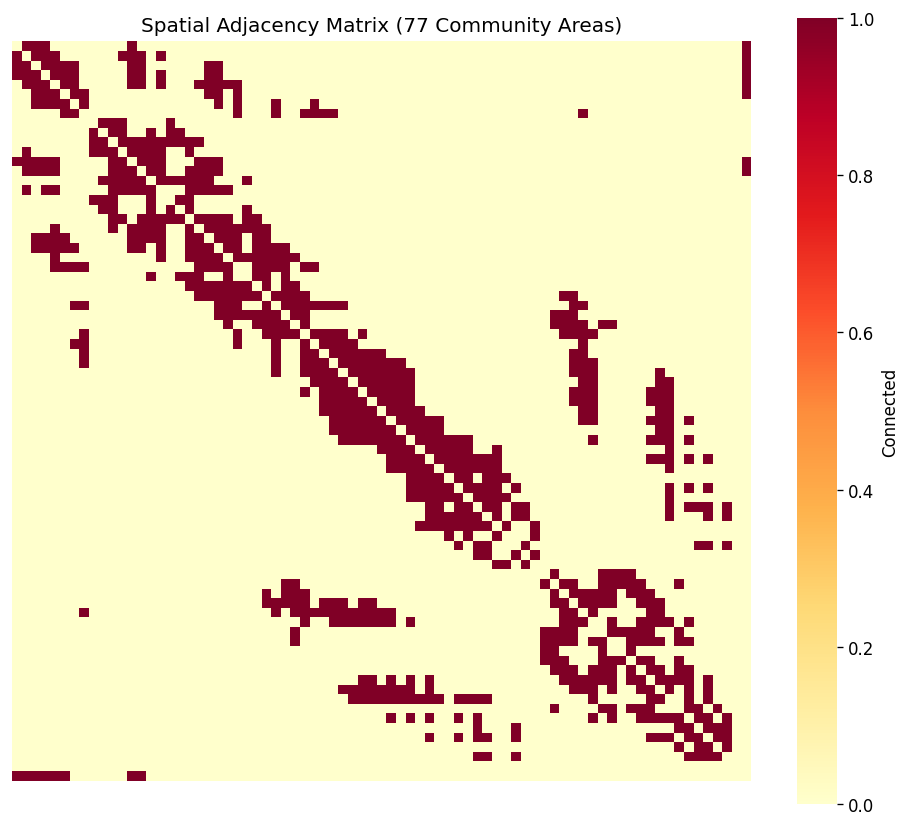

In [60]:
#build adjacency matrix
from scipy.spatial.distance import cdist
#compute centroid for each community area
centroids = (
    df.groupby('Community Area')[['Latitude', 'Longitude']]
      .mean()
      .sort_index()
)
NODES = centroids.index.values          # sorted community area IDs
NUM_NODES = len(NODES)
node_to_idx = {n: i for i, n in enumerate(NODES)}

#pairwise haversine-ish distance in degrees
dist_matrix = cdist(centroids.values, centroids.values, metric='euclidean')
DIST_THRESHOLD = np.percentile(dist_matrix[dist_matrix > 0], 15)
adj = (dist_matrix < DIST_THRESHOLD).astype(float)
np.fill_diagonal(adj, 0)

#row-normalise for GCN
row_sum = adj.sum(axis=1, keepdims=True)
row_sum[row_sum == 0] = 1
adj_norm = adj / row_sum

print(f"Nodes (Community Areas): {NUM_NODES}")
print(f"Distance threshold     : {DIST_THRESHOLD:.4f} deg")
print(f"Edges                  : {int(adj.sum())}")

#visualise adjacency
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(adj, cmap='YlOrRd', square=True, cbar_kws={'label': 'Connected'},
            xticklabels=False, yticklabels=False, ax=ax)
ax.set_title(f'Spatial Adjacency Matrix ({NUM_NODES} Community Areas)')
plt.tight_layout()
plt.show()

In [61]:
#compute Chebyshev polynomials of the Laplacian
def scaled_laplacian(adj_mx):
    n = adj_mx.shape[0]
    d = np.diag(adj_mx.sum(axis=1))
    lap = d - adj_mx
    #eigenvalues for scaling
    eigvals = np.linalg.eigvalsh(lap)
    lambda_max = eigvals[-1]
    if lambda_max == 0:
        lambda_max = 1.0
    lap_scaled = (2.0 * lap / lambda_max) - np.eye(n)
    return lap_scaled
def cheb_polynomials(L_tilde, K):
    n = L_tilde.shape[0]
    polys = [np.eye(n), L_tilde.copy()]
    for k in range(2, K):
        polys.append(2 * L_tilde @ polys[-1] - polys[-2])
    return [torch.FloatTensor(p) for p in polys[:K]]

K_ORDER = 3  #chebyshev polynomial order
L_tilde = scaled_laplacian(adj)
cheb_polys = cheb_polynomials(L_tilde, K_ORDER)
print(f"Chebyshev polynomials computed: K={K_ORDER}, each shape={cheb_polys[0].shape}")

Chebyshev polynomials computed: K=3, each shape=torch.Size([77, 77])


### 2c · Temporal Aggregation — Sliding Windows

Takes the timestamps and groups them into sliding time windows.  
Aggregate crime counts per **(week, Community Area)** and build features.  
Then create sliding windows: given `T_in` past weeks, predict the next `T_out` weeks.  
Both outputs combine into a single **spatio-temporal tensor** `(batch, T_in, N_nodes, F_features)`.

In [62]:
#aggregate weekly crime features per community area
agg = (
    df.groupby(['week', 'Community Area'])
      .agg(
          crime_count   = ('Date', 'size'),
          arrest_rate   = ('Arrest', 'mean'),
          domestic_rate = ('Domestic', 'mean'),
          avg_hour      = ('hour', 'mean'),
          weekend_frac  = ('is_weekend', 'mean'),
          n_crime_types = ('crime_type_enc', 'nunique'),
      )
      .reset_index()
)
weeks_sorted = sorted(agg['week'].unique())
week_to_idx  = {w: i for i, w in enumerate(weeks_sorted)}
NUM_WEEKS    = len(weeks_sorted)
FEATURE_COLS = ['crime_count', 'arrest_rate', 'domestic_rate',                'avg_hour', 'weekend_frac', 'n_crime_types']
NUM_FEATURES = len(FEATURE_COLS)
print(f"Total weeks   : {NUM_WEEKS}")
print(f"Features/node : {NUM_FEATURES}")
print(f"Tensor shape  : (weeks={NUM_WEEKS}, nodes={NUM_NODES}, feats={NUM_FEATURES})")

Total weeks   : 1176
Features/node : 6
Tensor shape  : (weeks=1176, nodes=77, feats=6)


In [63]:
#build spatio-temporal tensor
data_tensor = np.zeros((NUM_WEEKS, NUM_NODES, NUM_FEATURES), dtype=np.float32)

for _, row in tqdm(agg.iterrows(), total=len(agg), desc='Filling tensor'):
    t = week_to_idx[row['week']]
    n = node_to_idx.get(int(row['Community Area']))
    if n is not None:
        data_tensor[t, n] = row[FEATURE_COLS].values.astype(np.float32)
data_tensor[:, :, 0] = np.log1p(data_tensor[:, :, 0])

raw_crime_counts = data_tensor[:, :, 0].copy()

#normalise features
scaler = StandardScaler()
orig_shape = data_tensor.shape
data_flat = data_tensor.reshape(-1, NUM_FEATURES)
data_flat = scaler.fit_transform(data_flat)
data_tensor = data_flat.reshape(orig_shape)

print(f"Normalised spatio-temporal tensor shape: {data_tensor.shape}")

Filling tensor:   0%|          | 0/88308 [00:00<?, ?it/s]

Normalised spatio-temporal tensor shape: (1176, 77, 6)


In [64]:
#create sliding-window samples
T_IN  = 1
T_OUT = 1

class CrimeDataset(Dataset):
    """Sliding-window dataset over the spatio-temporal tensor."""

    def __init__(self, tensor, t_in, t_out):
        self.tensor = tensor
        self.t_in   = t_in
        self.t_out  = t_out
        self.total_windows = tensor.shape[0] - t_in - t_out + 1

    def __len__(self):
        return self.total_windows

    def __getitem__(self, idx):
        x = self.tensor[idx : idx + self.t_in]
        y = self.tensor[idx + self.t_in : idx + self.t_in + self.t_out, :, 0]
        return torch.FloatTensor(x), torch.FloatTensor(y.squeeze(0))

# Train / Val / Test split
n_total = data_tensor.shape[0] - T_IN - T_OUT + 1
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)

train_data = data_tensor[:n_train + T_IN + T_OUT - 1]
val_data   = data_tensor[n_train : n_train + n_val + T_IN + T_OUT - 1]
test_data  = data_tensor[n_train + n_val :]

train_ds = CrimeDataset(train_data, T_IN, T_OUT)
val_ds   = CrimeDataset(val_data,   T_IN, T_OUT)
test_ds  = CrimeDataset(test_data,  T_IN, T_OUT)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Samples → train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")
# Verify shapes
x_sample, y_sample = train_ds[0]
print(f"x shape: {x_sample.shape}  →  (T_in={T_IN}, N={NUM_NODES}, F={NUM_FEATURES})")
print(f"y shape: {y_sample.shape}  →  (N={NUM_NODES},) — crime count per area")

Samples → train: 822, val: 176, test: 177
x shape: torch.Size([1, 77, 6])  →  (T_in=1, N=77, F=6)
y shape: torch.Size([77])  →  (N=77,) — crime count per area


---
## 3 · ASTGCN Deep-Learning Core

The heart of the system — three layers stacked in sequence:

1. **Temporal Attention Layer** — looks across different time steps and learns which past moments are most relevant to the prediction (e.g., "last Tuesday evening matters more than last Tuesday morning").
2. **ST Convolution Block** — the actual "learning" step, combining:
   - A **Chebyshev graph convolution** (learns spatial patterns)
   - A **1-D temporal convolution** (learns time patterns)
   - A **ReLU activation** (adds non-linearity so it can learn complex patterns)

In [65]:
#Temporal Attention Layer
class TemporalAttention(nn.Module):
    def __init__(self, num_nodes, num_features, num_timesteps):
        super().__init__()
        self.U1 = nn.Parameter(torch.randn(num_nodes))
        self.U2 = nn.Parameter(torch.randn(num_features, num_nodes))
        self.U3 = nn.Parameter(torch.randn(num_features))
        self.be = nn.Parameter(torch.randn(1, num_timesteps, num_timesteps))
        self.Ve = nn.Parameter(torch.randn(num_timesteps, num_timesteps))

    def forward(self, x):
        B, T, N, Fin = x.shape

        lhs = torch.einsum('btni,n->bti', x, self.U1)
        lhs = torch.einsum('btf,fn->btn', lhs, self.U2)

        rhs = torch.einsum('btnf,f->btn', x, self.U3)
        rhs = rhs.permute(0, 2, 1)

        product = torch.sigmoid(torch.bmm(lhs, rhs) + self.be)

        e = torch.matmul(self.Ve, product)
        e = F.softmax(e, dim=-1)

        out = torch.einsum('bts,bsnf->btnf', e, x)
        return out

In [66]:
class SpatialAttention(nn.Module):
    def __init__(self, num_nodes, num_features, num_timesteps):
        super().__init__()
        self.W1 = nn.Parameter(torch.randn(num_timesteps, num_features) * 0.1)
        self.W2 = nn.Parameter(torch.randn(num_features) * 0.1)
        self.bs = nn.Parameter(torch.zeros(1, num_nodes, num_nodes))
        self.Vs = nn.Parameter(torch.randn(num_nodes, num_nodes) * 0.1)

    def forward(self, x):
        xp = x.permute(0, 2, 1, 3)

        summary = torch.einsum('bntf,tf->bnf', xp, self.W1)

        lhs = summary
        rhs = summary * self.W2

        product = torch.bmm(lhs, rhs.transpose(1, 2))
        product = torch.sigmoid(product + self.bs)

        s = self.Vs * product
        s = F.softmax(s, dim=-1)
        return s

In [67]:
class ChebGraphConv(nn.Module):
    def __init__(self, K, f_in, f_out, cheb_polynomials):
        super().__init__()
        self.K = K
        self.cheb_polynomials = cheb_polynomials
        self.weights = nn.ParameterList(
            [nn.Parameter(torch.randn(f_in, f_out) * 0.1) for _ in range(K)]
        )
        self.bias = nn.Parameter(torch.zeros(1, 1, f_out))

    def forward(self, x, spatial_attn=None):
        B, N, F_in = x.shape
        outputs = []
        for k in range(self.K):
            T_k = self.cheb_polynomials[k].to(x.device)
            if spatial_attn is not None:
                T_k = T_k.unsqueeze(0) * spatial_attn
                rhs = torch.einsum('bmn,bnf->bmf', T_k, x)
            else:
                rhs = torch.einsum('mn,bnf->bmf', T_k, x)
            rhs = torch.matmul(rhs, self.weights[k])
            outputs.append(rhs)
        out = sum(outputs) + self.bias
        return out

In [68]:
class STConvBlock(nn.Module):
    def __init__(self, K, f_in, f_spatial, f_out, num_nodes,
                 cheb_polynomials, temporal_kernel=3):
        super().__init__()
        self.graph_conv = ChebGraphConv(K, f_in, f_spatial, cheb_polynomials)
        self.temporal_conv = nn.Conv2d(
            in_channels=f_spatial, out_channels=f_out,
            kernel_size=(temporal_kernel, 1), padding=(temporal_kernel // 2, 0)
        )
        self.layer_norm = nn.LayerNorm([f_out])

    def forward(self, x, spatial_attn=None):
        B, T, N, F_in = x.shape
        gc_out = [self.graph_conv(x[:, t], spatial_attn) for t in range(T)]
        gc_out = torch.stack(gc_out, dim=1).permute(0, 3, 1, 2)
        tc_out = self.temporal_conv(gc_out).permute(0, 2, 3, 1)
        return F.relu(self.layer_norm(tc_out))

In [69]:
class ASTGCN(nn.Module):
    def __init__(self, num_nodes, num_features, num_timesteps_in,
                 cheb_polynomials, K=3, hidden_spatial=32, hidden_out=16,
                 temporal_kernel=3):
        super().__init__()

        self.temporal_attention = TemporalAttention(num_nodes, num_features, num_timesteps_in)
        self.spatial_attention = SpatialAttention(num_nodes, num_features, num_timesteps_in)

        self.st_block1 = STConvBlock(K=K, f_in=num_features, f_spatial=hidden_spatial,
                                      f_out=hidden_spatial, num_nodes=num_nodes,
                                      cheb_polynomials=cheb_polynomials, temporal_kernel=temporal_kernel)
        self.st_block2 = STConvBlock(K=K, f_in=hidden_spatial, f_spatial=hidden_out,
                                      f_out=hidden_out, num_nodes=num_nodes,
                                      cheb_polynomials=cheb_polynomials, temporal_kernel=temporal_kernel)

        t_rem = num_timesteps_in
        self.fc = nn.Linear(t_rem * hidden_out, 1)
        self.correction_weight = nn.Parameter(torch.tensor(1.0))

    def forward(self, x):
        residual = x[:, -1, :, 0]

        h = self.temporal_attention(x)
        s = self.spatial_attention(h)

        h = self.st_block1(h, s)
        h = self.st_block2(h, s)

        B, T_rem, N, H = h.shape
        h_flat = h.permute(0, 2, 1, 3).reshape(B, N, T_rem * H)
        correction = self.fc(h_flat).squeeze(-1)

        return residual + self.correction_weight * correction

In [70]:
#instantiate model
model = ASTGCN(
    num_nodes        = NUM_NODES,
    num_features     = NUM_FEATURES,
    num_timesteps_in = T_IN,
    cheb_polynomials = cheb_polys,
    K                = K_ORDER,
    hidden_spatial   = 32,
    hidden_out       = 16,
    temporal_kernel  = 3
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(model)

Model parameters: 18,579
ASTGCN(
  (temporal_attention): TemporalAttention()
  (spatial_attention): SpatialAttention()
  (st_block1): STConvBlock(
    (graph_conv): ChebGraphConv(
      (weights): ParameterList(
          (0): Parameter containing: [torch.float32 of size 6x32 (cuda:0)]
          (1): Parameter containing: [torch.float32 of size 6x32 (cuda:0)]
          (2): Parameter containing: [torch.float32 of size 6x32 (cuda:0)]
      )
    )
    (temporal_conv): Conv2d(32, 32, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
    (layer_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  )
  (st_block2): STConvBlock(
    (graph_conv): ChebGraphConv(
      (weights): ParameterList(
          (0): Parameter containing: [torch.float32 of size 32x16 (cuda:0)]
          (1): Parameter containing: [torch.float32 of size 32x16 (cuda:0)]
          (2): Parameter containing: [torch.float32 of size 32x16 (cuda:0)]
      )
    )
    (temporal_conv): Conv2d(16, 16, kernel_size=(3, 

---
## 4 · Prediction Output Head — Training & Evaluation

A **fully connected layer** takes everything the core learned and maps it down to the final numeric output — essentially converting the model's internal understanding into predicted crime numbers.

In [71]:
EPOCHS     = 20
LR         = 1e-3
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)
criterion = nn.MSELoss()

In [72]:
#training & validation
train_losses, val_losses = [], []
best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    #train
    model.train()
    epoch_loss = 0.0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        y_pred = model(x_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        epoch_loss += loss.item() * x_batch.size(0)
    train_losses.append(epoch_loss / len(train_ds))

    #validate
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            y_pred = model(x_batch)
            val_loss += criterion(y_pred, y_batch).item() * x_batch.size(0)
    val_losses.append(val_loss / len(val_ds))

    scheduler.step(val_losses[-1])

    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        torch.save(model.state_dict(), 'astgcn_best.pt')

    if epoch % 5 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:3d}/{EPOCHS} │ "
              f"Train MSE: {train_losses[-1]:.4f} │ "
              f"Val MSE: {val_losses[-1]:.4f} │ "
              f"LR: {lr_now:.2e}")

print(f"\n✓ Best Val MSE: {best_val_loss:.4f}")

Epoch   1/20 │ Train MSE: 0.1572 │ Val MSE: 0.0556 │ LR: 1.00e-03
Epoch   5/20 │ Train MSE: 0.0644 │ Val MSE: 0.0552 │ LR: 1.00e-03
Epoch  10/20 │ Train MSE: 0.0654 │ Val MSE: 0.0552 │ LR: 5.00e-04
Epoch  15/20 │ Train MSE: 0.0637 │ Val MSE: 0.0552 │ LR: 5.00e-04
Epoch  20/20 │ Train MSE: 0.0654 │ Val MSE: 0.0552 │ LR: 2.50e-04

✓ Best Val MSE: 0.0552


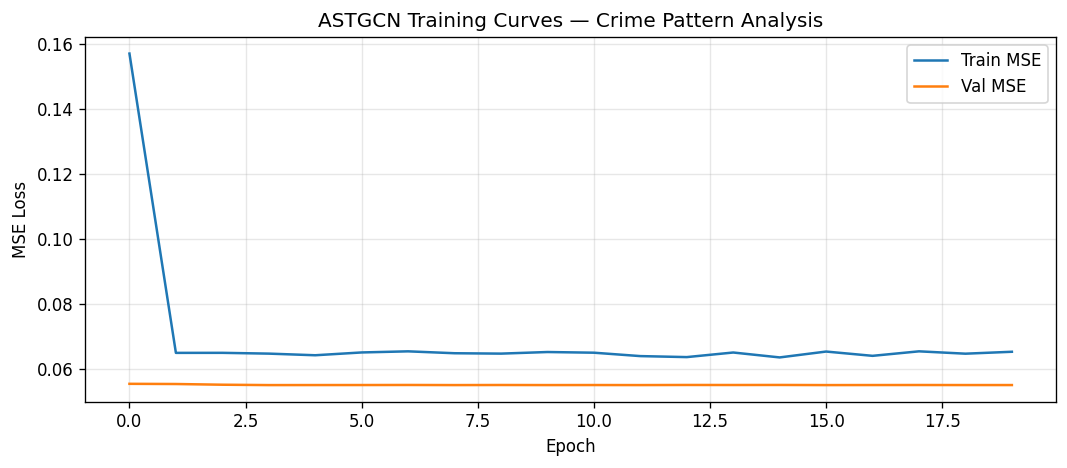

In [73]:
#loss curves
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, label='Train MSE')
ax.plot(val_losses,   label='Val MSE')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('ASTGCN Training Curves — Crime Pattern Analysis')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('ASTGCN_training_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [74]:
#load best model & predict on test set
model.load_state_dict(torch.load('astgcn_best.pt', map_location=DEVICE))
model.eval()

all_preds, all_trues = [], []
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(DEVICE)
        preds = model(x_batch).cpu().numpy()
        all_preds.append(preds)
        all_trues.append(y_batch.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_trues = np.concatenate(all_trues, axis=0)

print(f"Test predictions shape: {all_preds.shape}")

Test predictions shape: (177, 77)


In [75]:
#inverse transform the crime_count column
mean_cc, std_cc = scaler.mean_[0], scaler.scale_[0]

preds_log = all_preds * std_cc + mean_cc
trues_log = all_trues * std_cc + mean_cc

preds_real = np.expm1(preds_log)
trues_real = np.expm1(trues_log)

preds_real = np.clip(preds_real, 0, None)
trues_real = np.clip(trues_real, 0, None)

mae  = mean_absolute_error(trues_real.flatten(), preds_real.flatten())
rmse = np.sqrt(mean_squared_error(trues_real.flatten(), preds_real.flatten()))
r2   = r2_score(trues_real.flatten(), preds_real.flatten())

print(f"  Test MAE  : {mae:.2f}")
print(f"  Test RMSE : {rmse:.2f}")
print(f"  Test R²   : {r2:.4f}")

  Test MAE  : 9.49
  Test RMSE : 15.37
  Test R²   : 0.8899


In [76]:
print(f"  Mean actual count : {trues_real.mean():.2f}")
print(f"  Std  actual count : {trues_real.std():.2f}")
print(f"  Max  actual count : {trues_real.max():.2f}")

  Mean actual count : 54.58
  Std  actual count : 46.34
  Max  actual count : 568.00


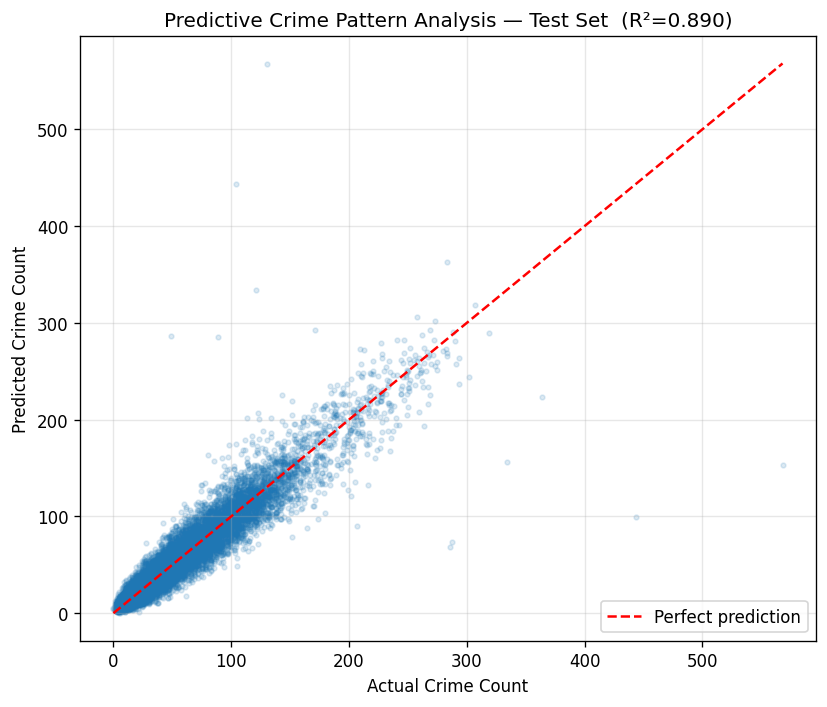

In [77]:
#actual vs Predicted scatter plot
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(trues_real.flatten(), preds_real.flatten(), alpha=0.15, s=8)
mn, mx = 0, max(trues_real.max(), preds_real.max())
ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Crime Count')
ax.set_ylabel('Predicted Crime Count')
ax.set_title(f'Predictive Crime Pattern Analysis — Test Set  (R²={r2:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('predictive_crime_pattern_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [78]:
print("Train samples with true count > 300:", (trues_real > 300).sum(), "out of", trues_real.size)
print("Train samples with true count > 400:", (trues_real > 400).sum())
print("Percentage of all samples above 300:", 100 * (trues_real > 300).mean(), "%")

Train samples with true count > 300: 7 out of 13629
Train samples with true count > 400: 2
Percentage of all samples above 300: 0.05136106831022085 %


---
## 5 · Final Forecast — Crime Density Matrix & Hotspot Evolution Map

Two outputs come out at the end:
1. **Crime Density Matrix** — the raw predicted numbers, laid out as a grid.
2. **Hotspot Evolution Map** — the same predictions turned into a visual map, showing how hotspots are expected to shift or grow over time.

### 5a · Crime Density Matrix (Prediction Table)

In [79]:
#crime density matrix: last 8 test windows
N_SHOW = min(8, all_preds.shape[0])
density_matrix = pd.DataFrame(
    preds_real[-N_SHOW:].T,
    index=[f"Area {n}" for n in NODES],
    columns=[f"Week t+{i+1}" for i in range(N_SHOW)]
)
density_matrix = density_matrix.round(1)

print("\nCrime Density Matrix (predicted weekly crimes per community area):")
density_matrix


Crime Density Matrix (predicted weekly crimes per community area):


,Week t+1,Week t+2,Week t+3,Week t+4,Week t+5,Week t+6,Week t+7,Week t+8
Area 1,71.9,75.9,100.8,91.8,91.8,85.9,79.9,92.8
Area 2,79.9,76.9,73.9,79.9,64.9,70.9,74.9,94.8
Area 3,85.9,81.9,111.8,102.8,73.9,91.8,102.8,104.8
Area 4,46.9,42.9,43.9,33.9,52.9,39.9,37.9,45.9
Area 5,25.0,19.0,20.0,31.9,30.9,33.9,32.9,25.0
...,...,...,...,...,...,...,...,...
Area 73,64.9,52.9,92.8,61.9,65.9,58.9,62.9,57.9
Area 74,11.0,13.0,11.0,7.0,9.0,8.0,3.0,8.0
Area 75,38.9,38.9,33.9,35.9,35.9,36.9,31.9,33.9
Area 76,40.0,40.0,34.0,27.0,31.0,36.0,30.0,24.0


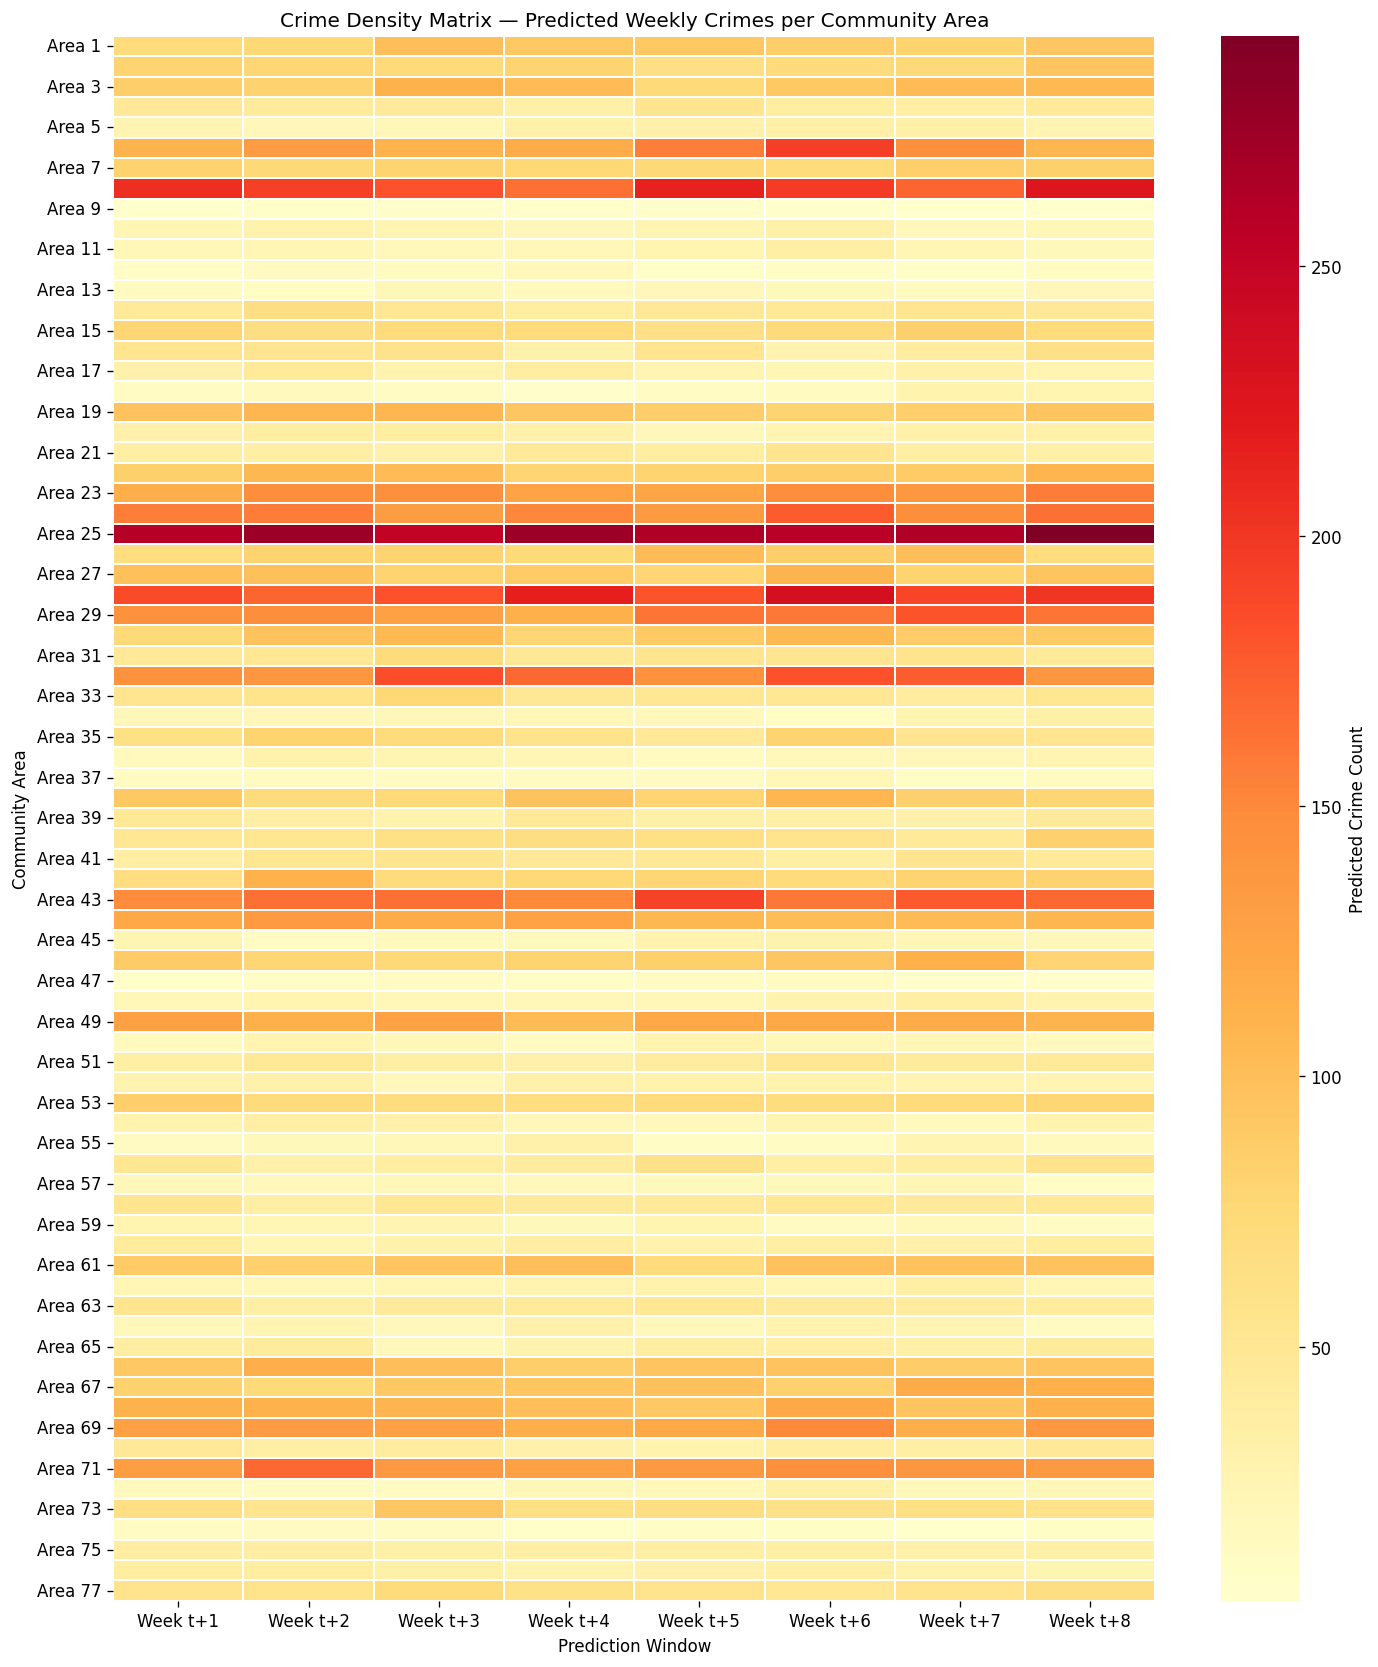

In [80]:
#heatmap of the density matrix
fig, ax = plt.subplots(figsize=(12, 14))
sns.heatmap(density_matrix.astype(float), cmap='YlOrRd', annot=False,
            linewidths=0.1, ax=ax,
            cbar_kws={'label': 'Predicted Crime Count'})
ax.set_title('Crime Density Matrix — Predicted Weekly Crimes per Community Area')
ax.set_xlabel('Prediction Window')
ax.set_ylabel('Community Area')
plt.tight_layout()
fig.savefig('crime_density_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

### 5b · Hotspot Evolution Map

In [81]:
#hotspot transition labels the actual evolution
HOTSPOT_QUANTILE = 0.80

def hotspot_labels(weekly_counts_2d):
    thresholds = np.quantile(weekly_counts_2d, HOTSPOT_QUANTILE, axis=1, keepdims=True)
    return (weekly_counts_2d >= thresholds).astype(np.int64)

hotspot_flags = hotspot_labels(raw_crime_counts)

TRANSITION_NAMES = ["EMERGING", "PERSISTING", "DISSIPATING", "STABLE_NORMAL"]
EMERGING, PERSISTING, DISSIPATING, STABLE_NORMAL = range(4)
TREND_TOL = 0.15

def compute_transitions(prev_hot, curr_hot, prev_count, curr_count):
    out = np.full(prev_hot.shape, STABLE_NORMAL, dtype=np.int64)
    both0  = (prev_hot == 0) & (curr_hot == 0)
    emerge = (prev_hot == 0) & (curr_hot == 1)
    dissip = (prev_hot == 1) & (curr_hot == 0)
    both1  = (prev_hot == 1) & (curr_hot == 1)
    rel_change = (curr_count - prev_count) / (prev_count + 1e-6)

    out[both0]  = STABLE_NORMAL
    out[emerge] = EMERGING
    out[dissip] = DISSIPATING
    out[both1 & (rel_change >= -TREND_TOL) & (rel_change <= TREND_TOL)] = PERSISTING
    return out

print("Transition classes:", TRANSITION_NAMES)

Transition classes: ['EMERGING', 'PERSISTING', 'DISSIPATING', 'STABLE_NORMAL']


In [82]:
class EvolutionDataset(Dataset):
    def __init__(self, tensor, raw_counts, hot_flags, t_in, t_out):
        self.tensor     = tensor
        self.raw_counts = raw_counts
        self.hot_flags  = hot_flags
        self.t_in  = t_in
        self.t_out = t_out
        self.total_windows = tensor.shape[0] - t_in - t_out + 1

    def __len__(self):
        return self.total_windows

    def __getitem__(self, idx):
        x = self.tensor[idx : idx + self.t_in]
        y_count = self.tensor[idx + self.t_in : idx + self.t_in + self.t_out, :, 0]

        prev_idx = idx + self.t_in - 1
        curr_idx = idx + self.t_in
        y_trans = compute_transitions(
            self.hot_flags[prev_idx], self.hot_flags[curr_idx],
            self.raw_counts[prev_idx], self.raw_counts[curr_idx]
        )

        return (torch.FloatTensor(x),
                torch.FloatTensor(y_count.squeeze(0)),
                torch.LongTensor(y_trans))

n_total = data_tensor.shape[0] - T_IN - T_OUT + 1
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)

train_data_e, train_raw_e, train_hot_e = data_tensor[:n_train+T_IN+T_OUT-1], raw_crime_counts[:n_train+T_IN+T_OUT-1], hotspot_flags[:n_train+T_IN+T_OUT-1]
val_data_e,   val_raw_e,   val_hot_e   = data_tensor[n_train:n_train+n_val+T_IN+T_OUT-1], raw_crime_counts[n_train:n_train+n_val+T_IN+T_OUT-1], hotspot_flags[n_train:n_train+n_val+T_IN+T_OUT-1]
test_data_e,  test_raw_e,  test_hot_e  = data_tensor[n_train+n_val:], raw_crime_counts[n_train+n_val:], hotspot_flags[n_train+n_val:]

train_ds_e = EvolutionDataset(train_data_e, train_raw_e, train_hot_e, T_IN, T_OUT)
val_ds_e   = EvolutionDataset(val_data_e,   val_raw_e,   val_hot_e,   T_IN, T_OUT)
test_ds_e  = EvolutionDataset(test_data_e,  test_raw_e,  test_hot_e,  T_IN, T_OUT)

train_loader_e = DataLoader(train_ds_e, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader_e   = DataLoader(val_ds_e,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader_e  = DataLoader(test_ds_e,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Evolution samples → train: {len(train_ds_e)}, val: {len(val_ds_e)}, test: {len(test_ds_e)}")
class_counts = np.bincount(np.array([train_ds_e[i][2].numpy() for i in range(len(train_ds_e))]).ravel(), minlength=6)
for name, c in zip(TRANSITION_NAMES, class_counts):
    print(f"  {name:14s}: {c:5d}  ({100*c/class_counts.sum():.1f}%)")

Evolution samples → train: 822, val: 176, test: 177
  EMERGING      :  1894  (3.0%)
  PERSISTING    : 11294  (17.8%)
  DISSIPATING   :  1894  (3.0%)
  STABLE_NORMAL : 48212  (76.2%)


In [83]:
#ASTGCN Evolution
class ASTGCN_Evolution(nn.Module):
    def __init__(self, num_nodes, num_features, num_timesteps_in,
                 cheb_polynomials, K=3, hidden_spatial=32, hidden_out=16,
                 temporal_kernel=3, num_classes=6):
        super().__init__()
        self.temporal_attention = TemporalAttention(num_nodes, num_features, num_timesteps_in)
        self.st_block1 = STConvBlock(K=K, f_in=num_features, f_spatial=hidden_spatial,
                                      f_out=hidden_spatial, num_nodes=num_nodes,
                                      cheb_polynomials=cheb_polynomials, temporal_kernel=temporal_kernel)
        self.st_block2 = STConvBlock(K=K, f_in=hidden_spatial, f_spatial=hidden_out,
                                      f_out=hidden_out, num_nodes=num_nodes,
                                      cheb_polynomials=cheb_polynomials, temporal_kernel=temporal_kernel)
        t_rem = num_timesteps_in
        self.fc_count = nn.Linear(t_rem * hidden_out, 1)
        self.correction_weight = nn.Parameter(torch.tensor(1.0))

        self.fc_transition = nn.Linear(t_rem * hidden_out, num_classes)

    def forward(self, x):
        residual = x[:, -1, :, 0]

        h = self.temporal_attention(x)
        h = self.st_block1(h)
        h = self.st_block2(h)

        B, T_rem, N, H = h.shape
        h_flat = h.permute(0, 2, 1, 3).reshape(B, N, T_rem * H)

        count_correction = self.fc_count(h_flat).squeeze(-1)
        count_pred = residual + self.correction_weight * count_correction

        transition_logits = self.fc_transition(h_flat)

        return count_pred, transition_logits

In [84]:
model_evo = ASTGCN_Evolution(
    num_nodes=NUM_NODES, num_features=NUM_FEATURES, num_timesteps_in=T_IN,
    cheb_polynomials=cheb_polys, K=K_ORDER, hidden_spatial=32, hidden_out=16,
    temporal_kernel=3, num_classes=6
).to(DEVICE)

train_labels_flat = np.array([train_ds_e[i][2].numpy() for i in range(len(train_ds_e))]).ravel()
cc = np.bincount(train_labels_flat, minlength=6).astype(np.float32)
class_weights = torch.tensor(cc.sum() / (cc + 1e-6), dtype=torch.float32)
class_weights = (class_weights / class_weights.sum() * 6).to(DEVICE)
print("class weights:", dict(zip(TRANSITION_NAMES, class_weights.tolist())))

optimizer_e = torch.optim.Adam(model_evo.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler_e = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_e, 'min', patience=5, factor=0.5)
count_loss_fn = nn.MSELoss()
trans_loss_fn = nn.CrossEntropyLoss(weight=class_weights)

best_val_e = float('inf')
for epoch in range(1, EPOCHS + 1):
    model_evo.train()
    ep_loss = 0.0
    for x_b, yc_b, yt_b in train_loader_e:
        x_b, yc_b, yt_b = x_b.to(DEVICE), yc_b.to(DEVICE), yt_b.to(DEVICE)
        optimizer_e.zero_grad()
        pred_c, pred_t = model_evo(x_b)
        loss = count_loss_fn(pred_c, yc_b) + trans_loss_fn(pred_t.reshape(-1, 6), yt_b.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_evo.parameters(), max_norm=5.0)
        optimizer_e.step()
        ep_loss += loss.item() * x_b.size(0)
    train_loss = ep_loss / len(train_ds_e)

    model_evo.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_b, yc_b, yt_b in val_loader_e:
            x_b, yc_b, yt_b = x_b.to(DEVICE), yc_b.to(DEVICE), yt_b.to(DEVICE)
            pred_c, pred_t = model_evo(x_b)
            loss = count_loss_fn(pred_c, yc_b) + trans_loss_fn(pred_t.reshape(-1, 6), yt_b.reshape(-1))
            val_loss += loss.item() * x_b.size(0)
    val_loss /= len(val_ds_e)
    scheduler_e.step(val_loss)

    if val_loss < best_val_e:
        best_val_e = val_loss
        torch.save(model_evo.state_dict(), 'astgcn_evolution_best.pt')

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} │ Train {train_loss:.4f} │ Val {val_loss:.4f}")

model_evo.load_state_dict(torch.load('astgcn_evolution_best.pt', map_location=DEVICE))
print(f"\n✓ Best val loss: {best_val_e:.4f}")

class weights: {'EMERGING': 1.5839493050506803e-09, 'PERSISTING': 2.65627769779897e-10, 'DISSIPATING': 1.5839493050506803e-09, 'STABLE_NORMAL': 6.222516946152723e-11}
Epoch   1/20 │ Train 1.5834 │ Val 1.4394
Epoch   5/20 │ Train 0.9513 │ Val 0.9455
Epoch  10/20 │ Train 0.6441 │ Val 0.6781
Epoch  15/20 │ Train 0.5740 │ Val 0.7287
Epoch  20/20 │ Train 0.5410 │ Val 0.6324

✓ Best val loss: 0.6324


In [85]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

model_evo.eval()
all_pred_c, all_true_c, all_pred_t, all_true_t = [], [], [], []
with torch.no_grad():
    for x_b, yc_b, yt_b in test_loader_e:
        pred_c, pred_t = model_evo(x_b.to(DEVICE))
        all_pred_c.append(pred_c.cpu().numpy()); all_true_c.append(yc_b.numpy())
        all_pred_t.append(pred_t.argmax(-1).cpu().numpy()); all_true_t.append(yt_b.numpy())

pred_c = np.concatenate(all_pred_c); true_c = np.concatenate(all_true_c)
pred_t = np.concatenate(all_pred_t); true_t = np.concatenate(all_true_t)


preds_real = np.expm1(np.clip(pred_c * std_cc + mean_cc, None, None))
trues_real = np.expm1(np.clip(true_c * std_cc + mean_cc, None, None))
preds_real = np.clip(preds_real, 0, None)
trues_real = np.clip(trues_real, 0, None)

print(f"Count MAE: {mean_absolute_error(trues_real.flatten(), preds_real.flatten()):.2f}")

acc = accuracy_score(true_t.ravel(), pred_t.ravel())
_, _, f1, _ = precision_recall_fscore_support(true_t.ravel(), pred_t.ravel(), labels=range(6), average="macro", zero_division=0)
print(f"\nTransition Accuracy: {acc:.3f}   Macro-F1: {f1:.3f}\n")
print(classification_report(true_t.ravel(), pred_t.ravel(), labels=range(6), target_names=TRANSITION_NAMES, zero_division=0))

Count MAE: 10.61

Transition Accuracy: 0.853   Macro-F1: 0.354

               precision    recall  f1-score   support

     EMERGING       0.16      0.56      0.25       320
   PERSISTING       0.93      0.62      0.74      2530
  DISSIPATING       0.11      0.34      0.17       320
STABLE_NORMAL       0.99      0.94      0.96     10459

     accuracy                           0.85     13629
    macro avg       0.37      0.41      0.35     13629
 weighted avg       0.94      0.85      0.88     13629



In [86]:
print("preds_real range:", preds_real.min(), preds_real.max())
print("trues_real range:", trues_real.min(), trues_real.max())

preds_real range: 0.1270378412251181 512.9557880272511
trues_real range: 3.349739075601846e-08 568.000222930916


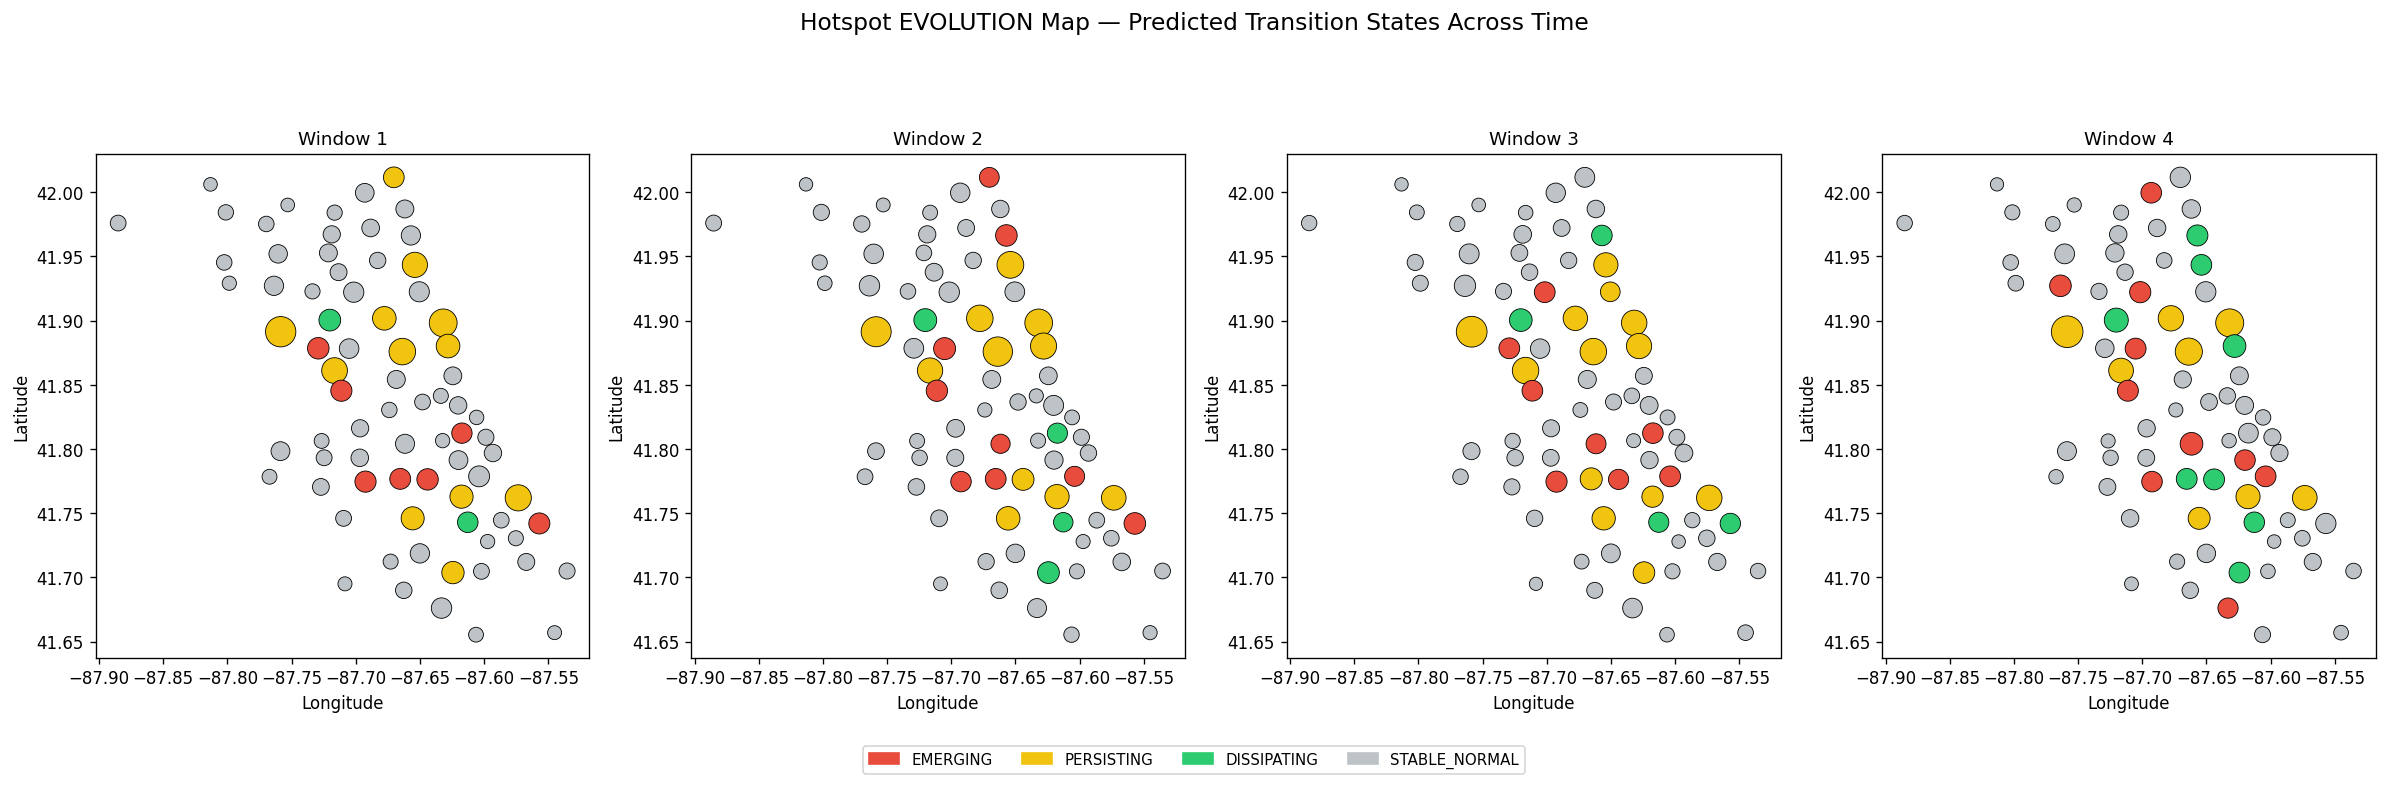

In [87]:
#hotspot evolution
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

TRANSITION_COLORS = {
    EMERGING:      "#e74c3c",  # red    - new hotspot forming
    PERSISTING:    "#f1c40f",  # yellow - staying a hotspot
    DISSIPATING:   "#2ecc71",  # green  - hotspot going away
    STABLE_NORMAL: "#bdc3c7",  # grey   - nothing happening
}
cmap = ListedColormap([TRANSITION_COLORS[i] for i in range(4)])
norm = BoundaryNorm(np.arange(-0.5, 4.5, 1), cmap.N)

N_PANELS = min(4, pred_t.shape[0])
fig, axes = plt.subplots(1, N_PANELS, figsize=(5 * N_PANELS, 6))
if N_PANELS == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    idx = -(N_PANELS - i)
    trans_week = pred_t[idx]
    count_week = preds_real[idx]

    sizes = 60 + 300 * (count_week / (preds_real[-N_PANELS:].max() + 1e-6))

    sc = ax.scatter(
        centroids['Longitude'].values,
        centroids['Latitude'].values,
        c=trans_week,
        cmap=cmap,
        norm=norm,
        s=sizes,
        edgecolors='k',
        linewidths=0.5,
    )
    ax.set_title(f'Window {i + 1}', fontsize=11)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_aspect('equal')

handles = [mpatches.Patch(color=c, label=TRANSITION_NAMES[i]) for i, c in TRANSITION_COLORS.items()]
fig.legend(handles=handles, loc='lower center', ncol=6, fontsize=9, bbox_to_anchor=(0.5, -0.05))

fig.suptitle('Hotspot EVOLUTION Map — Predicted Transition States Across Time',
             fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig('hotspot_evolution_transition_map.png', dpi=300, bbox_inches='tight')
plt.show()

### 5c · Top-N Most Dangerous Areas

In [88]:
#rank community areas by predicted crime
avg_pred = preds_real.mean(axis=0)
ranking = pd.DataFrame({
    'Community Area': NODES,
    'Avg Predicted Crimes/Week': avg_pred.round(1),
    'Centroid Lat': centroids['Latitude'].values,
    'Centroid Lon': centroids['Longitude'].values,
}).sort_values('Avg Predicted Crimes/Week', ascending=False).reset_index(drop=True)

ranking.index += 1
ranking.index.name = 'Rank'

print("\nTop 15 Community Areas by Predicted Weekly Crime Count:")
ranking.head(15)


Top 15 Community Areas by Predicted Weekly Crime Count:


,Community Area,Avg Predicted Crimes/Week,Centroid Lat,Centroid Lon
Rank,,,,
1,25,218.4,41.891326,-87.758519
2,8,156.2,41.898213,-87.631931
3,28,145.5,41.875844,-87.663774
4,43,133.5,41.761933,-87.573452
5,29,115.4,41.861079,-87.716543
6,24,112.8,41.901768,-87.677773
7,32,111.4,41.880172,-87.628154
8,69,109.0,41.762855,-87.617665
9,23,103.0,41.900386,-87.720259


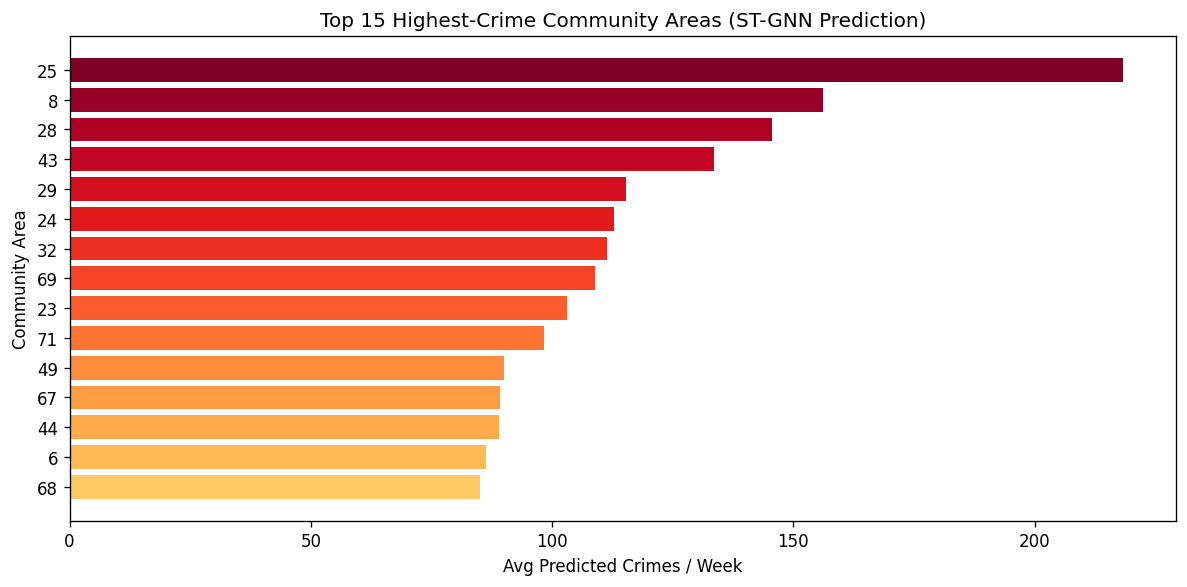

In [89]:
#bar chart of top 15
top15 = ranking.head(15)
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.YlOrRd(np.linspace(0.3, 1.0, 15))
ax.barh(top15['Community Area'].astype(str), top15['Avg Predicted Crimes/Week'],
        color=colors[::-1])
ax.set_xlabel('Avg Predicted Crimes / Week')
ax.set_ylabel('Community Area')
ax.set_title('Top 15 Highest-Crime Community Areas (ST-GNN Prediction)')
ax.invert_yaxis()
plt.tight_layout()
fig.savefig('highest_crime_community_area.png', dpi=300, bbox_inches='tight')
plt.show()

### 5d · Temporal Attention Visualization

In [90]:
persistence_pred = trues_real[:, :-1]
mae_persistence = mean_absolute_error(trues_real[1:].flatten(), trues_real[:-1].flatten())
print(f"Persistence baseline MAE: {mae_persistence:.2f}")

historical_mean_pred = np.full_like(trues_real, trues_real.mean())
mae_histmean = mean_absolute_error(trues_real.flatten(), historical_mean_pred.flatten())
print(f"Historical-mean baseline MAE: {mae_histmean:.2f}")

Persistence baseline MAE: 9.50
Historical-mean baseline MAE: 35.23


In [91]:
print(model.correction_weight.item())

0.9780835509300232


---
## 📋 Summary — Spatio-Temporal Graph Neural Network with Attention for Predictive Crime Pattern Analysis and Hotspot Analysis

| Stage | Component | Details |
|---|---|---|
| **1** | Data Input Layer | Chicago Crimes 2001–2004 CSV — raw crime logs (Date, Primary Type, Community Area, Lat/Lon) + derived features (hour, day-of-week, weekend, arrest/domestic rates) |
| **2** | Data Pre-processing Module | Spatial graph (77 community-area nodes, Chebyshev polynomials K=3) + Temporal aggregation (weekly sliding windows) → spatio-temporal tensor `(B, 12, 77, 6)` |
| **3** | ASTGCN Deep-Learning Core | Temporal Attention → 2× ST-Conv Block (ChebGraphConv + 1D-TemporalConv + ReLU + LayerNorm) |
| **4** | Prediction Output Head | Fully-connected layer → `(B, 77)` predicted crime counts per community area |
| **5** | Final Forecast | **Crime Density Matrix** (prediction table) + **Hotspot Evolution Map** (visual spatial heatmap over time) |

### Outputs
- **Crime Density Matrix** — predicted weekly crime counts for each of 77 community areas
- **Hotspot Evolution Map** — spatial heatmap showing how crime hotspots shift over time
- **Top-N Ranking** — community areas ranked by predicted crime intensity
- **Temporal Attention Visualization** — which past weeks the model focuses on for prediction